# Predicting AI Efficiency and Business Impact in Organisations Based on Adoption Rate
### ENGE707 Phase 1 — Data Engineering & Exploratory Data Analysis

**Dataset:** AI Company Adoption survey (`ai_company_adoption.csv`) — 150,000 quarterly company
records, 43 features, 2023–2026.

**Background.** Organisations are investing heavily in AI, but the outcomes vary widely — some
companies see strong productivity and revenue gains, while others experience high failure rates
and stalled maturity. Relatively few studies quantitatively link *investment* (training, budget,
per-employee spend) and *governance* to adoption success.

**Problem.** Using this dataset, the project predicts a company's AI adoption maturity stage from
investment and governance features, and examines how that maturity relates to downstream business
outcomes.

**Feature groups used throughout this notebook:**
| Role | Features |
|---|---|
| Primary (target) | `ai_adoption_stage`, `ai_adoption_rate` |
| Secondary (predictors) | `ai_training_hours`, `ai_budget_percentage`, `ai_maturity_score`, `ai_failure_rate`, `ai_investment_per_employee` |
| Tertiary (outcomes) | `revenue_growth_percent`, `cost_reduction_percent`, `reskilled_employees` |

`ai_investment_per_employee` is already a per-employee measure, so wherever it is analysed below
it is paired with `company_size` / `num_employees` rather than compared on its own — otherwise a
"per employee" figure would be interpreted as if it were a company-level total.

Phase 1 covers problem definition, data acquisition/inspection, cleansing, and EDA only — feature
engineering and model training are out of scope here and will follow in later phases.

## Task 1 — Problem Definition and Dataset Selection

- **Source:** AI Company Adoption dataset (Kaggle-style open synthetic survey), provided as
  `ai_company_adoption.csv`.
- **Structure:** tabular, alpha-numeric, 150,000 rows × 43 columns — satisfies the ">20 and
  <300 features" requirement.
- **Unit of observation:** one row = one company's survey response for one quarter (a company
  can appear in the dataset multiple times, once per quarter, identified by `company_id`).
- **Stakeholders:** company leadership deciding how much to invest in AI; HR/L&D teams sizing
  training programmes; investors and policymakers assessing where AI investment pays off.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)


## Task 2 — Data Acquisition, Inspection, and Documentation

### Load the dataset

In [2]:
df = pd.read_csv("ai_company_adoption.csv")

print("Shape:", df.shape)
df.head()


Shape: (150000, 43)


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,company_founding_year,company_age,company_age_group,ai_adoption_rate,ai_adoption_stage,years_using_ai,ai_primary_tool,num_ai_tools_used,ai_use_case,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_maturity_score,ai_failure_rate,ai_investment_per_employee,regulatory_compliance_score,data_privacy_level,ai_ethics_committee,ai_risk_management_score,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,30.57,pilot,3,ChatGPT,1,Customer Support,3,20.94,6.54,0.224,35.22,55392.29,60,Medium,No,60,14.55,6.95,19.47,6.44,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,27.25,pilot,4,ChatGPT,3,Software Development,0,23.10,5.81,0.174,24.65,49210.79,68,High,No,53,50.25,5.16,26.24,8.92,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,31.54,pilot,2,Custom Internal AI,3,HR Automation,3,12.29,12.39,0.266,36.51,105011.76,66,High,No,53,41.70,4.57,22.24,7.59,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,11.02,pilot,2,Custom Internal AI,1,Software Development,2,11.31,3.20,0.123,33.30,27157.71,64,High,No,44,28.10,5.33,2.87,3.16,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,1994,30,16-30 years,33.39,pilot,7,ChatGPT,3,Customer Support,5,35.17,9.98,0.363,19.83,84622.90,68,High,Yes,77,29.93,6.00,18.44,7.03,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  str    
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  str    
 4   country                      150000 non-null  str    
 5   region                       150000 non-null  str    
 6   industry                     150000 non-null  str    
 7   company_size                 150000 non-null  str    
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_age                  150000 non-null  int64  
 12  company_age_group            150000 non-null  str    
 13  ai_adoptio

### Convert free-text categorical columns to `category` dtype
This is the data-engineering equivalent of correcting data types before analysis — pandas'
`category` dtype stores each value once instead of repeating the string, and groupby operations
below run faster and more predictably as a result.

In [4]:
categorical_cols = [
    "country", "region", "industry", "company_size", "quarter",
    "ai_adoption_stage", "ai_primary_tool", "ai_use_case",
    "company_age_group", "data_privacy_level", "ai_ethics_committee",
    "survey_source", "data_collection_method",
]
for col in categorical_cols:
    df[col] = df[col].astype("category")

print(df.dtypes.value_counts())


float64     15
int64       14
str          1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


### Keep an untouched copy of the raw data
All inspection and cleaning below works on copies; `df_original` itself is never modified.

In [5]:
df_original = df.copy(deep=True)

print("Records:", df_original.shape[0])
print("Columns:", df_original.shape[1])
print("\nAdoption-stage categories:", df_original["ai_adoption_stage"].cat.categories.tolist())


Records: 150000
Columns: 43

Adoption-stage categories: ['full', 'none', 'partial', 'pilot']


### Inspect data quality before deciding what to clean
Missing values, duplicate rows/IDs, logically inconsistent records, and the value ranges of the
primary/secondary/tertiary features used in this project.

In [6]:
# Missing values
missing = df_original.isna().sum()
print("Columns containing missing values:")
print(missing[missing > 0].sort_values(ascending=False) if missing.sum() > 0 else "None found.")

# Duplicate rows / duplicate response IDs
print("\nNumber of fully duplicate rows:", df_original.duplicated().sum())
print("Number of duplicate response_id values:", df_original["response_id"].duplicated().sum())

# Logical consistency checks
inconsistent = (
    (df_original["years_using_ai"] > df_original["company_age"])
    | (df_original["num_employees"] <= 0)
    | (df_original["annual_revenue_usd_millions"] <= 0)
)
print("\nLogically inconsistent records (years_using_ai > company_age, or non-positive size/revenue):",
      inconsistent.sum())

# Ranges of the primary/secondary/tertiary features
key_cols = [
    "ai_adoption_rate", "ai_training_hours", "ai_budget_percentage", "ai_maturity_score",
    "ai_failure_rate", "ai_investment_per_employee",
    "revenue_growth_percent", "cost_reduction_percent", "reskilled_employees",
]
print("\nValue ranges:")
print(df_original[key_cols].agg(["min", "max"]).T)

print("\nRecords per adoption stage:")
print(df_original["ai_adoption_stage"].value_counts())


Columns containing missing values:
None found.

Number of fully duplicate rows: 0
Number of duplicate response_id values: 0

Logically inconsistent records (years_using_ai > company_age, or non-positive size/revenue): 0

Value ranges:
                            min          max
ai_adoption_rate            0.0      100.000
ai_training_hours           0.0       80.000
ai_budget_percentage        0.0       25.000
ai_maturity_score           0.0        0.904
ai_failure_rate             0.0       40.000
ai_investment_per_employee  0.0  1898315.750
revenue_growth_percent     -5.0       30.000
cost_reduction_percent      0.0       20.790
reskilled_employees         0.0     3881.000

Records per adoption stage:
ai_adoption_stage
partial    78800
pilot      64317
none        5198
full        1685
Name: count, dtype: int64


**Findings:** no missing values, no fully-duplicate rows, no duplicate `response_id`s, and no
logically inconsistent age/size/revenue records — this is a clean synthetic dataset. Value ranges
all look plausible except `ai_investment_per_employee`, which is heavily right-skewed (max ≈
$1.9M vs a median of roughly $43k) — investigated as an outlier question in Task 3, not assumed to
be an error.

## Task 3 — Data Cleansing and Transformation

Because Task 2 found no missing values, duplicates, or logically invalid records, cleaning here is
mostly about **documenting that absence** and handling the one real data-quality question:
`ai_investment_per_employee`'s skew. The transformation function below is still written
defensively (median-fill, dedup, invalid-record removal) so the pipeline stays robust if a future
export of this survey does introduce such issues.

Decisions made and justified:
- **`response_id`** is dropped — it is a row index with no analytical value.
- **`company_id`** is kept — the same company appears across multiple quarters, and `company_id`
  is needed to avoid treating repeated observations of one company as independent evidence later.
- **`ai_adoption_stage`** gets an added ordinal encoding (`adoption_stage_ordinal`, none=0 →
  full=3) alongside the original category, since the four stages have a natural order that plain
  one-hot encoding would throw away.
- **`ai_investment_per_employee`** outliers are flagged with an IQR rule but *not* removed —
  extreme per-employee spend is plausible for a small, heavily-AI-invested startup, and the
  dataset documentation gives no reason to treat these as data-entry errors.

In [7]:
def clean_data(data):
    clean = data.copy(deep=True)

    # Logically invalid records (none currently found — kept for robustness)
    invalid_record = (
        (clean["years_using_ai"] > clean["company_age"])
        | (clean["num_employees"] <= 0)
        | (clean["annual_revenue_usd_millions"] <= 0)
    )
    print("Clearly invalid records removed:", invalid_record.sum())
    clean = clean.loc[~invalid_record].copy()

    # Defensive median-fill (no missing values currently, kept for robustness)
    for col in ["ai_maturity_score", "ai_failure_rate", "ai_investment_per_employee"]:
        clean[col] = clean[col].fillna(clean[col].median())

    # Ordinal encoding of the primary target, alongside the original category
    stage_order = ["none", "pilot", "partial", "full"]
    clean["adoption_stage_ordinal"] = clean["ai_adoption_stage"].map(
        {stage: i for i, stage in enumerate(stage_order)}
    )

    # Outlier flag (not removed) for the heavily skewed per-employee investment figure
    q1, q3 = clean["ai_investment_per_employee"].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    clean["high_investment_outlier"] = clean["ai_investment_per_employee"] > upper_fence

    # response_id has no analytical value
    clean = clean.drop(columns=["response_id"], errors="ignore")
    clean = clean.drop_duplicates()

    clean = clean.reset_index(drop=True)
    return clean


df_etl_clean = clean_data(df_original)

print("\nOriginal shape:", df_original.shape)
print("Cleaned shape:", df_etl_clean.shape)
print("adoption_stage_ordinal added:", "adoption_stage_ordinal" in df_etl_clean.columns)
print("Flagged as high-investment outliers:", df_etl_clean["high_investment_outlier"].sum(),
      f"({df_etl_clean['high_investment_outlier'].mean()*100:.1f}% of rows)")


Clearly invalid records removed: 0



Original shape: (150000, 43)
Cleaned shape: (150000, 44)
adoption_stage_ordinal added: True
Flagged as high-investment outliers: 12098 (8.1% of rows)


## Task 4 — Exploratory Data Analysis and Visualisation

### 4.1 Primary feature: AI adoption (rate and stage)

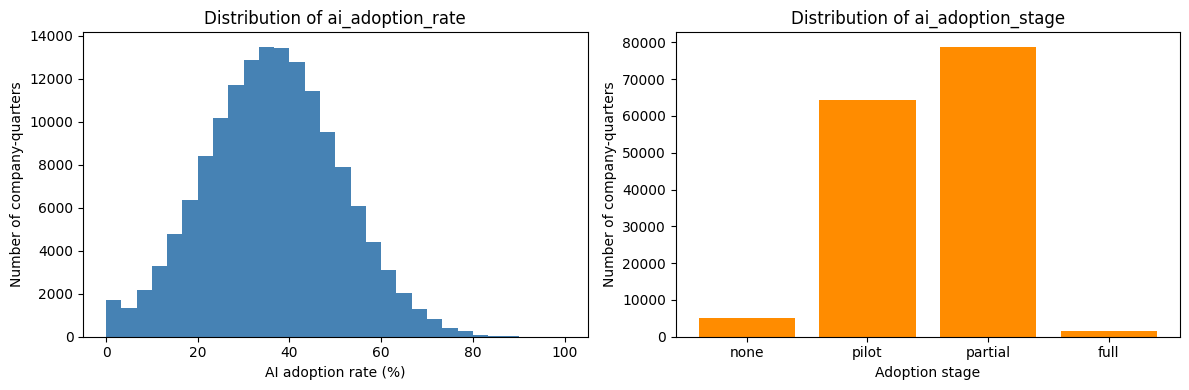

ai_adoption_stage
none        5198
pilot      64317
partial    78800
full        1685
Name: count, dtype: int64

Proportion of records at partial/full adoption: 0.537


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_etl_clean["ai_adoption_rate"].dropna(), bins=30, color="steelblue")
axes[0].set_xlabel("AI adoption rate (%)")
axes[0].set_ylabel("Number of company-quarters")
axes[0].set_title("Distribution of ai_adoption_rate")

stage_order = ["none", "pilot", "partial", "full"]
stage_counts = df_etl_clean["ai_adoption_stage"].value_counts().reindex(stage_order)
axes[1].bar(stage_counts.index, stage_counts.values, color="darkorange")
axes[1].set_xlabel("Adoption stage")
axes[1].set_ylabel("Number of company-quarters")
axes[1].set_title("Distribution of ai_adoption_stage")

plt.tight_layout()
plt.show()

print(stage_counts)
print("\nProportion of records at partial/full adoption:",
      round(df_etl_clean['ai_adoption_stage'].isin(['partial', 'full']).mean(), 3))


**Reading this:** adoption is skewed toward the middle of the journey — most company-quarters
sit at `pilot` or `partial`, `none` is rare (companies in this survey have mostly started
*something*), and `full` adoption is the least common stage, consistent with full-scale AI rollout
still being uncommon in 2023–2026.

### 4.2 Secondary features: investment and governance

In [9]:
secondary = ["ai_training_hours", "ai_budget_percentage", "ai_maturity_score",
             "ai_failure_rate", "ai_investment_per_employee"]

print(df_etl_clean[secondary].describe().round(2))
print("\nSkewness:")
print(df_etl_clean[secondary].skew().round(2))


       ai_training_hours  ai_budget_percentage  ai_maturity_score  \
count          150000.00             150000.00          150000.00   
mean               27.21                  9.51               0.34   
std                13.14                  3.84               0.13   
min                 0.00                  0.00               0.00   
25%                18.07                  6.88               0.25   
50%                27.06                  9.43               0.34   
75%                36.13                 12.08               0.44   
max                80.00                 25.00               0.90   

       ai_failure_rate  ai_investment_per_employee  
count        150000.00                   150000.00  
mean             25.77                    68726.33  
std               7.76                    86033.70  
min               0.00                        0.00  
25%              20.27                    21297.38  
50%              25.88                    43242.32  
75%    

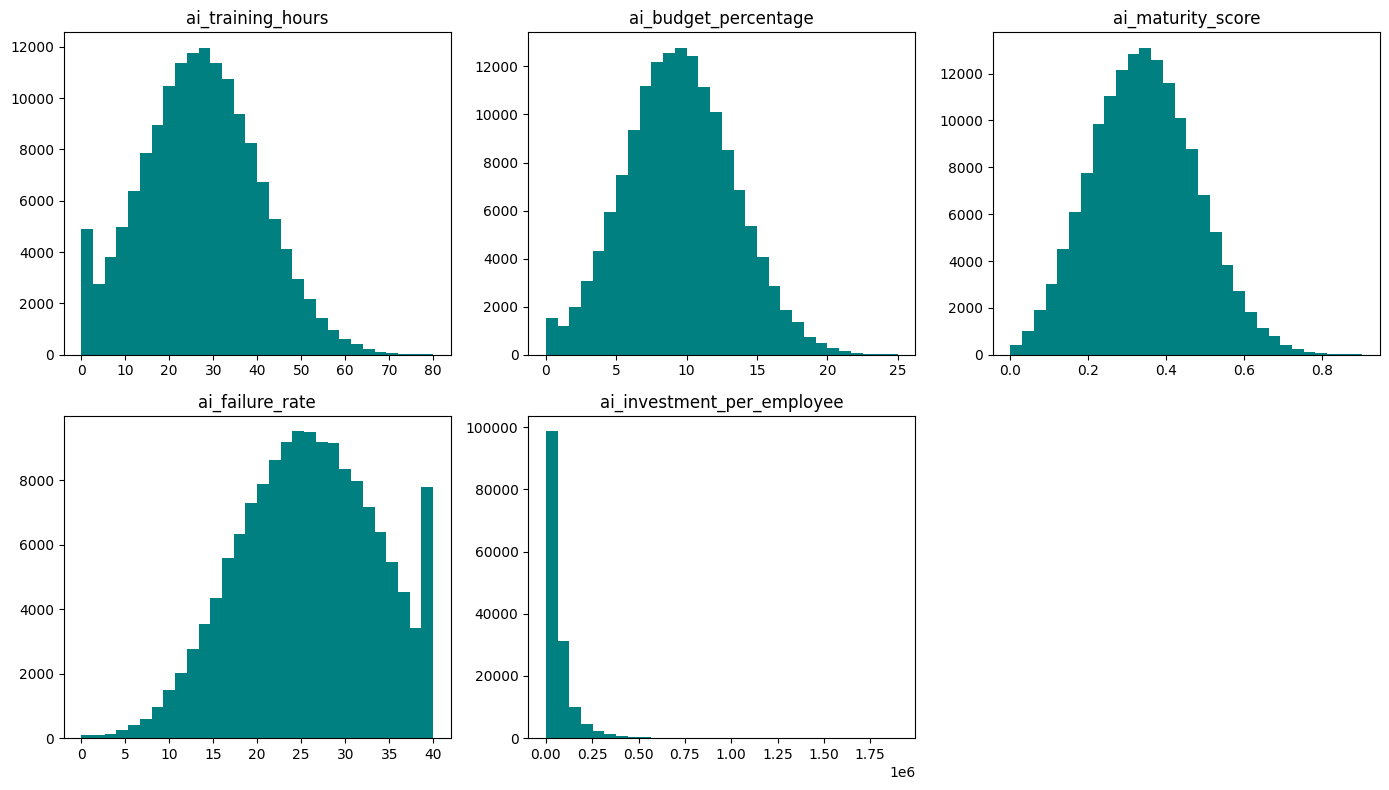

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, secondary):
    ax.hist(df_etl_clean[col].dropna(), bins=30, color="teal")
    ax.set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


`ai_investment_per_employee` is the clear outlier here (skew ≈ 4.3) — a long right tail of
heavily-funded companies, while `ai_training_hours`, `ai_budget_percentage`, `ai_maturity_score`,
and `ai_failure_rate` are all close to symmetric.

### 4.3 Outlier investigation — `ai_investment_per_employee`, by company size
Per the note above, a per-employee figure is only meaningful alongside company size, so the
boxplot below is split by `company_size` rather than shown alone.

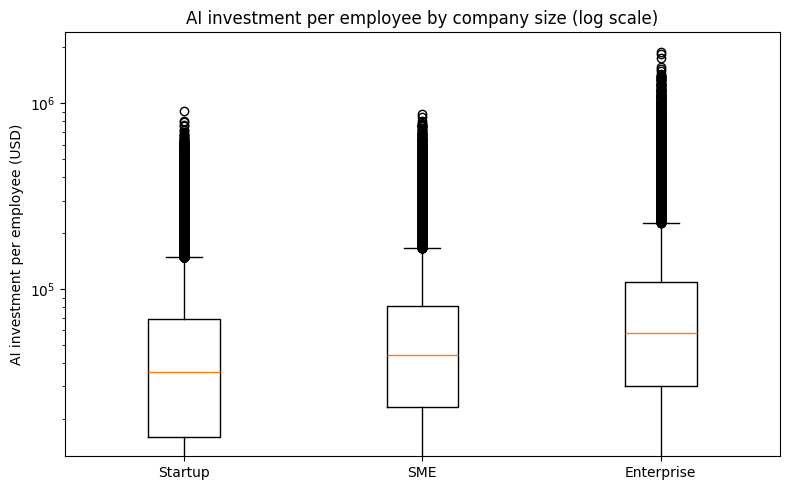

               median     mean        max
company_size                             
Enterprise    58243.0  97702.0  1898316.0
SME           44220.0  66296.0   880984.0
Startup       35670.0  56411.0   904074.0

High-investment outlier flag rate, by company size:
company_size
Enterprise    0.138
SME           0.074
Startup       0.058
Name: high_investment_outlier, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ["Startup", "SME", "Enterprise"]
data_by_size = [
    df_etl_clean.loc[df_etl_clean["company_size"] == size, "ai_investment_per_employee"].dropna()
    for size in order
]
ax.boxplot(data_by_size, tick_labels=order, vert=True)
ax.set_ylabel("AI investment per employee (USD)")
ax.set_yscale("log")
ax.set_title("AI investment per employee by company size (log scale)")
plt.tight_layout()
plt.show()

print(df_etl_clean.groupby("company_size", observed=True)["ai_investment_per_employee"]
      .agg(["median", "mean", "max"]).round(0))
print("\nHigh-investment outlier flag rate, by company size:")
print(df_etl_clean.groupby("company_size", observed=True)["high_investment_outlier"].mean().round(3))


Smaller companies spread AI budget over fewer staff, so their per-employee figures run higher
and more variable — this is a structural feature of the ratio, not evidence of bad data, which is
why these values were flagged rather than removed in Task 3.

### 4.4 Secondary features vs the primary target
Do investment and governance actually track adoption stage?

                   ai_training_hours  ai_budget_percentage  ai_maturity_score  \
ai_adoption_stage                                                               
none                            7.66                  3.56               0.12   
pilot                          19.85                  7.33               0.26   
partial                        33.95                 11.52               0.42   
full                           52.75                 17.21               0.65   

                   ai_failure_rate  ai_investment_per_employee  
ai_adoption_stage                                               
none                         33.41                    25376.27  
pilot                        30.78                    51542.54  
partial                      21.44                    84006.58  
full                         14.02                   143776.31  


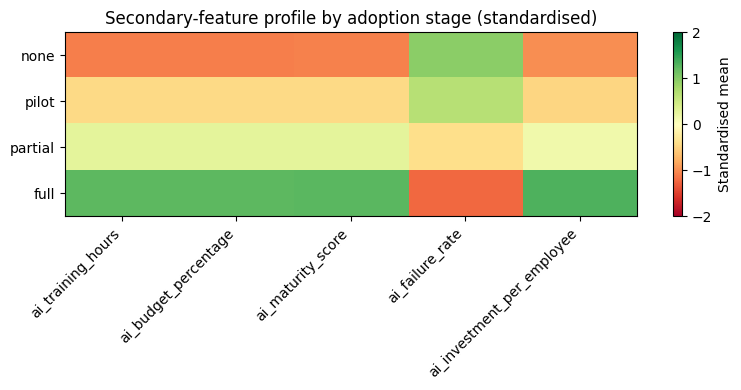

In [12]:
profile = (
    df_etl_clean
    .groupby("ai_adoption_stage", observed=True)[secondary]
    .mean()
    .reindex(stage_order)
)
print(profile.round(2))

profile_z = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(profile_z.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(secondary)))
ax.set_xticklabels(secondary, rotation=45, ha="right")
ax.set_yticks(range(len(stage_order)))
ax.set_yticklabels(stage_order)
ax.set_title("Secondary-feature profile by adoption stage (standardised)")
plt.colorbar(im, label="Standardised mean")
plt.tight_layout()
plt.show()


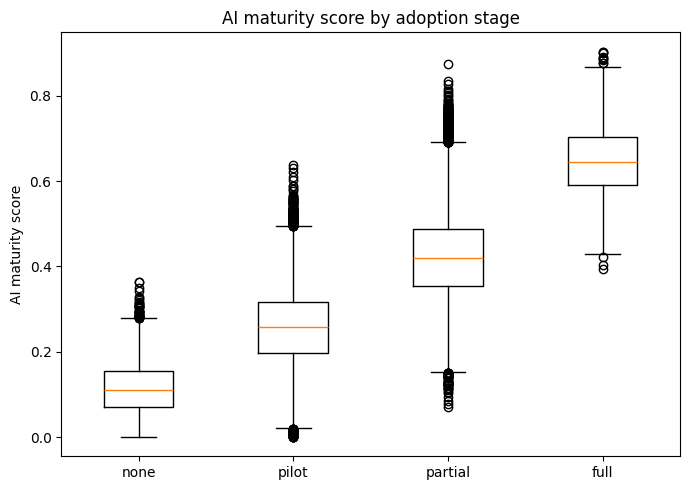

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
box_data = [df_etl_clean.loc[df_etl_clean["ai_adoption_stage"] == s, "ai_maturity_score"].dropna()
            for s in stage_order]
ax.boxplot(box_data, tick_labels=stage_order)
ax.set_ylabel("AI maturity score")
ax.set_title("AI maturity score by adoption stage")
plt.tight_layout()
plt.show()


Adoption stage tracks the secondary features almost monotonically: mean `ai_training_hours`,
`ai_budget_percentage`, and `ai_maturity_score` all rise from `none` → `full`, while
`ai_failure_rate` falls — companies further along the adoption journey report fewer AI-project
failures, not more, which argues against "more AI activity just means more visible failures."

### 4.5 Correlation between secondary and tertiary (outcome) features

                            ai_training_hours  ai_budget_percentage  \
ai_training_hours                        1.00                  0.56   
ai_budget_percentage                     0.56                  1.00   
ai_maturity_score                        0.82                  0.82   
ai_failure_rate                         -0.74                 -0.53   
ai_investment_per_employee               0.20                  0.35   
revenue_growth_percent                   0.35                  0.34   
cost_reduction_percent                   0.33                  0.33   
reskilled_employees                      0.34                  0.32   

                            ai_maturity_score  ai_failure_rate  \
ai_training_hours                        0.82            -0.74   
ai_budget_percentage                     0.82            -0.53   
ai_maturity_score                        1.00            -0.70   
ai_failure_rate                         -0.70             1.00   
ai_investment_per_employee    

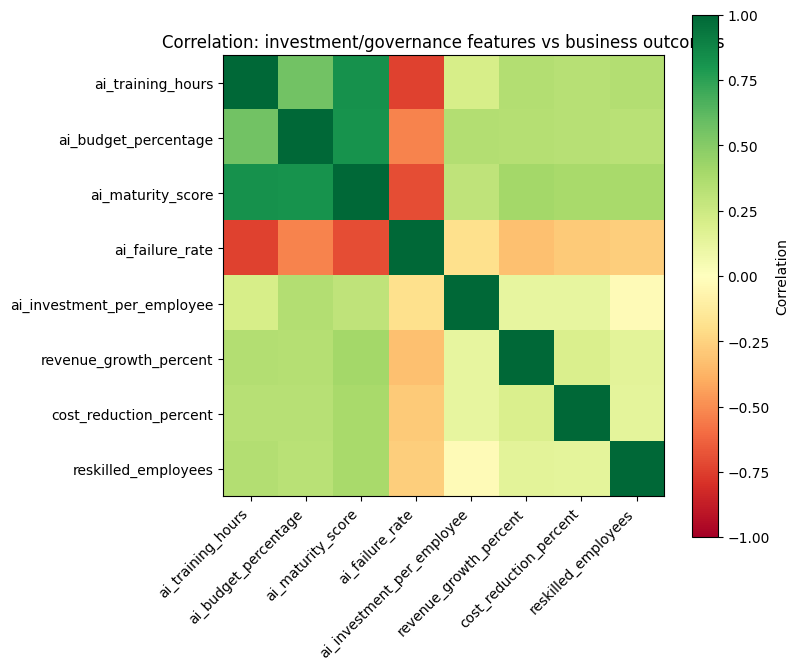

In [14]:
tertiary = ["revenue_growth_percent", "cost_reduction_percent", "reskilled_employees"]
num_cols = secondary + tertiary

corr_matrix = df_etl_clean[num_cols].corr()
print(corr_matrix.round(2))

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strongest = upper.abs().stack().idxmax()
print("\nStrongest absolute correlation:", strongest,
      round(corr_matrix.loc[strongest[0], strongest[1]], 2))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
plt.colorbar(im, label="Correlation")
ax.set_title("Correlation: investment/governance features vs business outcomes")
plt.tight_layout()
plt.show()


### 4.6 Tertiary (business outcome) features, by adoption stage

                   revenue_growth_percent  cost_reduction_percent  \
ai_adoption_stage                                                   
none                                 0.50                    2.19   
pilot                                2.89                    3.76   
partial                              6.15                    5.77   
full                                10.49                    8.59   

                   reskilled_employees  
ai_adoption_stage                       
none                             23.74  
pilot                            94.69  
partial                         253.49  
full                            627.81  


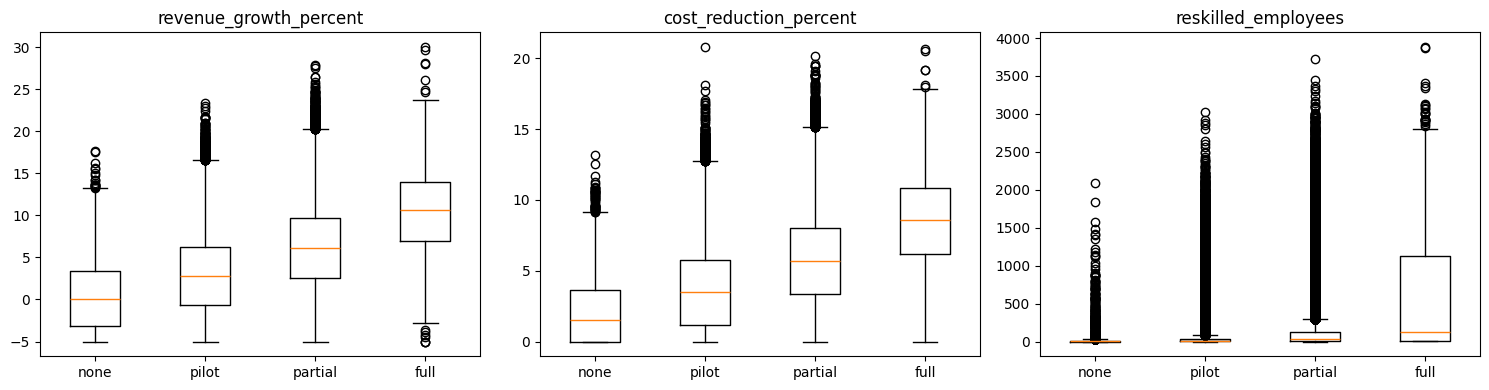

In [15]:
outcome_profile = (
    df_etl_clean
    .groupby("ai_adoption_stage", observed=True)[tertiary]
    .mean()
    .reindex(stage_order)
)
print(outcome_profile.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, tertiary):
    box_data = [df_etl_clean.loc[df_etl_clean["ai_adoption_stage"] == s, col].dropna()
                for s in stage_order]
    ax.boxplot(box_data, tick_labels=stage_order)
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 4.7 Maturity vs revenue growth, coloured by adoption stage
150,000 rows is too dense to plot meaningfully as-is, so (as would be justified in the written
report) a random sample is used for this scatter plot only — every statistic above still uses the
full cleaned dataset.

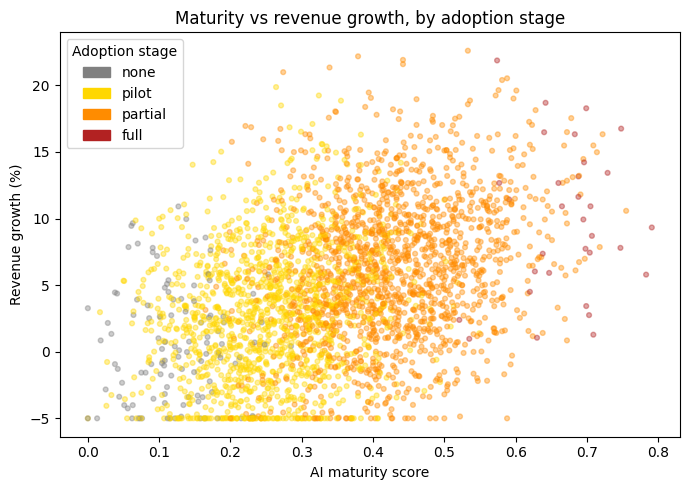

In [16]:
sample = df_etl_clean.sample(n=3000, random_state=42)
stage_colors = {"none": "grey", "pilot": "gold", "partial": "darkorange", "full": "firebrick"}
colors = sample["ai_adoption_stage"].map(stage_colors)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["ai_maturity_score"], sample["revenue_growth_percent"], c=colors, alpha=0.4, s=12)
ax.set_xlabel("AI maturity score")
ax.set_ylabel("Revenue growth (%)")
ax.set_title("Maturity vs revenue growth, by adoption stage")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=s) for s, c in stage_colors.items()], title="Adoption stage")
plt.tight_layout()
plt.show()


### 4.8 Missingness recap
Task 2 already found zero missing values across every column of the raw data; shown here as a
single check rather than a chart, since there is nothing to visualise.

In [17]:
miss_pct = df_original.isna().mean() * 100
print("Maximum missingness in any column:", miss_pct.max(), "%")
print("Columns with any missing data:", (miss_pct > 0).sum(), "of", len(miss_pct))


Maximum missingness in any column: 0.0 %
Columns with any missing data: 0 of 43


## Key data insights

1. **Adoption is skewed toward the middle of the journey.** Most company-quarters sit at `pilot`
   or `partial`; full-scale adoption (`full`) remains the rarest stage across 2023–2026.
2. **Investment and governance features track adoption stage almost monotonically.** Mean
   `ai_training_hours`, `ai_budget_percentage`, and `ai_maturity_score` rise steadily from `none`
   to `full`, while `ai_failure_rate` falls — companies further along the journey are not just
   spending more, they are also failing less often.
3. **`ai_investment_per_employee` is highly right-skewed** (skew ≈ 4.3) and needs to be read
   alongside company size: smaller companies post far higher per-employee figures for the same
   absolute AI budget, simply because that budget is divided across fewer staff. These values were
   flagged, not removed, since the dataset gives no basis for treating them as errors.
4. **Business outcomes rise with adoption stage.** Mean `revenue_growth_percent`,
   `cost_reduction_percent`, and `reskilled_employees` all increase from `none` through `full`,
   consistent with the project's framing that maturity, not adoption alone, is what links to
   downstream business impact.
5. **The dataset is clean.** No missing values, no duplicate rows or `response_id`s, and no
   logically inconsistent age/size/revenue records were found — cleaning in Task 3 was mostly
   about documenting that absence and building a defensively-written pipeline for future data.
6. These patterns motivate Phase 2: predicting `ai_adoption_stage` (or its ordinal encoding) from
   the secondary features, then testing whether predicted maturity explains variation in the
   tertiary business-outcome features.